<a href="https://colab.research.google.com/github/NguyenQuan297/CS4410_Assignment_Troy_2026Spring/blob/main/HomeWork5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ex 1:

### Load Iris Dataset

In [6]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data

### Apply Elbow Method

In [7]:
wcss = []

# Test k from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

    print(f"k = {k}, Inertia (WCSS) = {kmeans.inertia_:.2f}")

k = 1, Inertia (WCSS) = 681.37
k = 2, Inertia (WCSS) = 152.35
k = 3, Inertia (WCSS) = 78.85
k = 4, Inertia (WCSS) = 57.23
k = 5, Inertia (WCSS) = 46.46
k = 6, Inertia (WCSS) = 39.04
k = 7, Inertia (WCSS) = 34.31
k = 8, Inertia (WCSS) = 30.13
k = 9, Inertia (WCSS) = 28.29
k = 10, Inertia (WCSS) = 25.97


### Plot the Elbow Curve

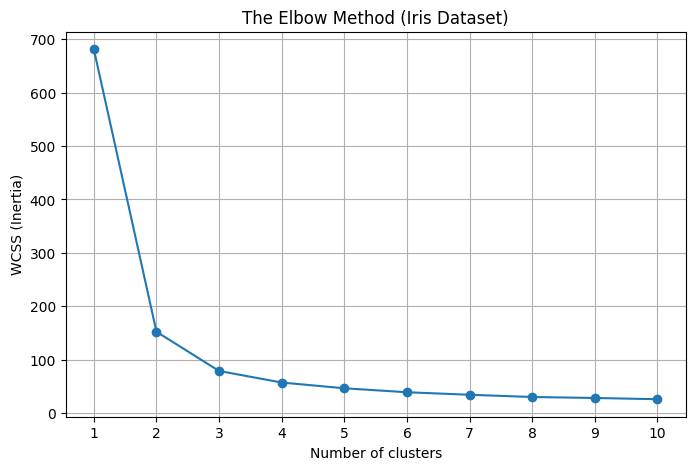

In [8]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method (Iris Dataset)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# Ex 2:

### Import Libraries

In [9]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

### Load MNIST Dataset

In [10]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

# Convert labels to integer
y = y.astype(int)

print("Dataset shape:", X.shape)

Dataset shape: (70000, 784)


### Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Logistic Regression WITHOUT PCA

In [13]:
# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

start = time.time()

model_no_pca = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model_no_pca.fit(X_train_scaled, y_train)

end = time.time()

y_pred_no_pca = model_no_pca.predict(X_test_scaled)

accuracy_no_pca = accuracy_score(y_test, y_pred_no_pca)

print("Without PCA")
print("Accuracy:", accuracy_no_pca)
print("Training Time:", end - start, "seconds")

Without PCA
Accuracy: 0.9154285714285715
Training Time: 55.42463755607605 seconds


### Logistic Regression WITH PCA (95% variance)

In [14]:
# Apply PCA
pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_scaled.shape[1])
print("Reduced features:", X_train_pca.shape[1])

start = time.time()

model_pca = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model_pca.fit(X_train_pca, y_train)

end = time.time()

y_pred_pca = model_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)

print("\nWith PCA (95% variance)")
print("Accuracy:", accuracy_pca)
print("Training Time:", end - start, "seconds")

Original features: 784
Reduced features: 330

With PCA (95% variance)
Accuracy: 0.9217857142857143
Training Time: 50.571683406829834 seconds
